In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import uproot
import glob
import awkward as ak

## FATRAS event 

In [2]:
fatras_dir = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100"

all_files = glob.glob(fatras_dir + "/*.root")

In [3]:
all_files

['/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/performance_finding_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/tracksummary_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/performance_finding_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/pythia8_vertices.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/performance_vertexing.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/trackstates_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/estimatedparams.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/hits.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/measurements.root',
 '/global/cfs/cdirs/m3443/usr/dtmu

In [4]:
# Uproot load 
hits_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/hits.root"
hits_tree = uproot.open(hits_file)

# Get the first entry in the tree
hits_tree.keys() # ['hits;7', 'hits;6']

# Get the hits data
hits_data_1 = hits_tree['hits;6'].arrays()
hits_data_2 = hits_tree['hits;7'].arrays()

print(f"Lengths: {len(hits_data_1)}, {len(hits_data_2)}")
print(f"Example of hits;6: {hits_data_1[0]}")
print(f"Example of hits;7: {hits_data_2[0]}")

Lengths: 5555472, 5812119
Example of hits;6: {event_id: 44, geometry_id: 1152921779484760322, particle_id: ..., ...}
Example of hits;7: {event_id: 44, geometry_id: 1152921779484760322, particle_id: ..., ...}


In [5]:
# Uproot load 
measurements_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_fatras_ttbar_100/measurements.root"
measurements_tree = uproot.open(measurements_file)

# Get the first entry in the tree
measurements_tree.keys() # ['measurements;13', 'measurements;12']

# Get the measurements data
measurements_data_1 = measurements_tree['measurements;13'].arrays()
measurements_data_2 = measurements_tree['measurements;12'].arrays()

print(f"Lengths: {len(measurements_data_1)}, {len(measurements_data_2)}")
print(f"Example of measurements;13: {measurements_data_1[0]}")
print(f"Example of measurements;12: {measurements_data_2[0]}")

Lengths: 5812119, 5649132
Example of measurements;13: {event_nr: 44, volume_id: 16, layer_id: 4, surface_id: 25, rec_loc0: 12.2, ...}
Example of measurements;12: {event_nr: 44, volume_id: 16, layer_id: 4, surface_id: 25, rec_loc0: 12.2, ...}


In [22]:
hits_data_1

<Array [{event_id: 44, ...}, {...}, ..., {...}] type='5555472 * {event_id: ...'>

In [6]:
# Get all hits from event 44
event_44_hits = hits_data_1[hits_data_1['event_id'] == 44]

# If you want to see the result:
print(f"Number of hits in event 44: {len(event_44_hits)}")

# Get all measurements from event 44
event_44_measurements = measurements_data_1[measurements_data_1['event_nr'] == 44]

# If you want to see the result:
print(f"Number of measurements in event 44: {len(event_44_measurements)}")

Number of hits in event 44: 45345
Number of measurements in event 44: 45345


## Geant4 event ttbar

In [3]:
geant_dir = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1"

all_files = glob.glob(geant_dir + "/*.root")

In [4]:
all_files

['/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/performance_finding_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/tracksummary_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/performance_finding_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/pythia8_vertices.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/performance_vertexing.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/trackstates_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/estimatedparams.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/hits.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/measurements.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_ou

In [5]:
# Uproot load 
hits_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/hits.root"
hits_tree = uproot.open(hits_file)

# Get the first entry in the tree
print(hits_tree.keys()) # ['hits;7', 'hits;6']

# Get the hits data
hits_data_1 = hits_tree['hits;1'].arrays()

print(f"Lengths: {len(hits_data_1)}")
print(f"Example of hits;6: {hits_data_1[0]}")

['hits;1']
Lengths: 119327
Example of hits;6: {event_id: 0, geometry_id: 1152921779484754433, particle_id: ..., ...}


In [6]:
particles_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/particles_simulation.root"
particles_tree = uproot.open(particles_file)

print(particles_tree.keys())
particles_data_2 = particles_tree['particles;1'].arrays()

print(f"Lengths: {len(particles_data_2)}")
print(f"Example of particles: {particles_data_2[0]}")


['particles;1']
Lengths: 1
Example of particles: {event_id: 0, particle_id: [4503599811919872, ...], particle_type: [...], ...}


In [7]:
particles_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/pythia8_particles.root"
particles_tree = uproot.open(particles_file)

print(particles_tree.keys())
particles_data_1 = particles_tree['particles;1'].arrays()

print(f"Lengths: {len(particles_data_1)}")
print(f"Example of particles: {particles_data_1[0]}")


['particles;1']
Lengths: 1
Example of particles: {event_id: 0, particle_id: [4503599644147712, ...], particle_type: [...], ...}


In [8]:
# This gives a multi index. Flatten that
particles_data_1 = ak.to_dataframe(particles_data_1)
particles_data_1 = particles_data_1.reset_index()
# Remove the "entry" and "subentry" columns
particles_data_1 = particles_data_1.drop(columns=["entry", "subentry"])

particles_data_2 = ak.to_dataframe(particles_data_2)
particles_data_2 = particles_data_2.reset_index()
# Remove the "entry" and "subentry" columns
particles_data_2 = particles_data_2.drop(columns=["entry", "subentry"])


In [9]:
# Check the overlap of particle_id in particles_data_1 and particles_data_2
(particles_data_1.particle_id.isin(particles_data_2.particle_id)).sum()

864

In [10]:
len(particles_data_1), len(particles_data_2)

(31083, 876)

In [11]:
particles_data_1

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
0,0,4503599644147712,22,0,-0.006878,0.006443,26.299278,2051.255127,-2.512112e-01,4.838016e-01,...,0.0,-5.478478,2.049721,5.451339e-01,6.527599e+01,1,0,1,0,0
1,0,4503599660924928,22,0,-0.006878,0.006443,26.299278,2051.255127,1.624675e+00,-2.493318e+00,...,0.0,-0.207040,-0.993289,2.975938e+00,3.039949e+00,1,0,2,0,0
2,0,4503599677702144,22,0,-0.006878,0.006443,26.299278,2051.255127,1.183492e-09,-7.022259e-10,...,0.0,0.384314,-0.535516,1.376145e-09,1.479029e-09,1,0,3,0,0
3,0,4503599694479360,2212,0,-0.006878,0.006443,26.299278,2051.255127,8.010023e-01,7.145254e-01,...,1.0,8.391574,0.728399,1.073383e+00,2.366676e+03,1,0,4,0,0
4,0,4503599711256576,-211,0,-0.006878,0.006443,26.299278,2051.255127,4.811529e-01,-3.089892e-01,...,-1.0,3.367633,-0.570862,5.718238e-01,8.304098e+00,1,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31078,0,900726523818934272,22,0,-0.037822,0.000961,-14.674923,-271.998077,-1.201986e-01,3.076893e-01,...,0.0,3.606828,1.943216,3.303338e-01,6.090716e+00,200,6,76,0,0
31079,0,900727623347339264,211,0,-2.949854,-3.117594,-622.231995,335.810150,1.517404e-01,-9.328608e-02,...,1.0,-4.708097,-0.551212,1.781220e-01,9.872420e+00,200,7,77,0,0
31080,0,900727623364116480,-211,0,-2.949854,-3.117594,-622.231995,335.810150,-2.357516e-01,3.324060e-03,...,-1.0,-4.173810,3.127494,2.357751e-01,7.660078e+00,200,7,78,0,0
31081,0,905223525118246912,2212,0,0.011007,0.008911,-32.753437,-1542.162964,-1.291707e-02,-5.197833e-02,...,1.0,12.473779,-1.814371,5.355929e-02,7.000000e+03,201,0,1,0,0


In [12]:
# Uproot load 
measurements_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_ttbar_1/measurements.root"
measurements_tree = uproot.open(measurements_file)

# Get the first entry in the tree
print(measurements_tree.keys()) # ['measurements;13', 'measurements;12']

# Get the measurements data
measurements_data_1 = measurements_tree['measurements;1'].arrays()

print(f"Lengths: {len(measurements_data_1)}")
print(f"Example of measurements;13: {measurements_data_1[0]}")

['measurements;1']
Lengths: 119327
Example of measurements;13: {event_nr: 0, volume_id: 16, layer_id: 4, surface_id: 2, rec_loc0: -12.2, ...}


In [13]:
hits_data_1

<Array [{event_id: 0, ...}, {...}, ..., {...}] type='119327 * {event_id: ui...'>

In [14]:
hits_data_1[0].fields

['event_id',
 'geometry_id',
 'particle_id',
 'tx',
 'ty',
 'tz',
 'tt',
 'tpx',
 'tpy',
 'tpz',
 'te',
 'deltapx',
 'deltapy',
 'deltapz',
 'deltae',
 'index',
 'volume_id',
 'boundary_id',
 'layer_id',
 'approach_id',
 'sensitive_id']

### Visualisation

In [15]:
sample_event_id = 0
sample_event_hits = hits_data_1[hits_data_1['event_id'] == sample_event_id]

In [16]:
# Convert to pandas
sample_event_hits = ak.to_dataframe(sample_event_hits)

In [17]:
sample_event_hits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
0,0,1152921779484754433,743093938851676160,92.744728,37.471458,-1516.800049,5773.597656,-0.174215,-0.052624,-0.166379,...,0.000440,-0.000913,-0.000005,-0.000096,10,16,0,4,0,2
1,0,1152921779484754433,607985950567563306,53.393082,13.119166,-1516.754395,1589.271362,0.000051,-0.000013,-0.000312,...,-0.000051,0.000013,0.000312,-0.000090,0,16,0,4,0,2
2,0,1152921779484754433,94575593449914381,100.903183,27.457563,-1516.800049,-1033.226562,0.661204,0.000277,-10.656444,...,-0.000240,0.000309,0.000023,-0.000038,7,16,0,4,0,2
3,0,1152921779484754689,846676731438825472,-66.247902,26.272223,-1515.599976,5854.194824,0.129556,0.097181,-0.046864,...,-0.000649,0.000694,0.000544,-0.000190,24,16,0,4,0,3
4,0,1152921779484754689,535928355892035602,-76.794151,55.778030,-1515.608154,2564.987793,-0.000244,-0.000721,-0.000626,...,0.000329,0.000408,-0.000185,-0.000098,0,16,0,4,0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119322,0,2161728645771608066,846676731808120854,327.698975,912.343079,3009.500000,1685.085327,-0.003866,-0.008170,0.022301,...,0.000466,0.000588,0.000186,-0.000090,2,30,0,12,0,192
119323,0,2161728645771608066,553942754804105216,395.501282,872.009460,3009.500000,4158.025879,0.315498,-0.007460,0.776173,...,-0.000013,-0.001171,-0.000124,-0.000107,16,30,0,12,0,192
119324,0,2161728645771608066,490892360876556288,372.597046,896.421570,3009.500000,4012.085693,-0.091376,0.532970,1.563411,...,-0.000645,0.000176,-0.000173,-0.000071,14,30,0,12,0,192


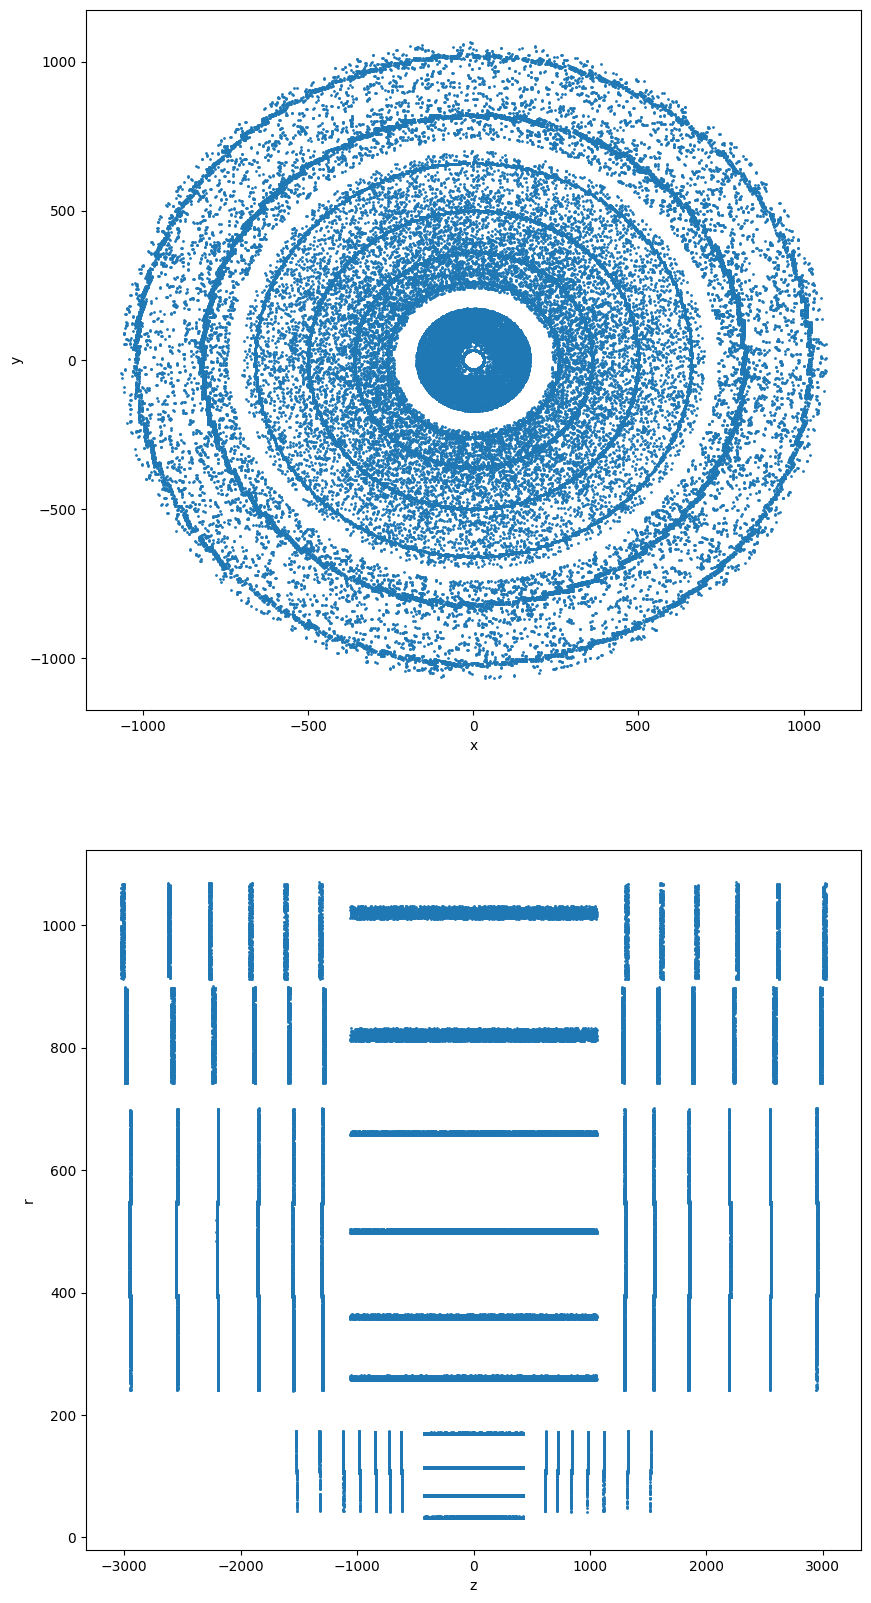

In [39]:
x, y, z = sample_event_hits['tx'], sample_event_hits['ty'], sample_event_hits['tz']
r, phi = np.sqrt(x**2 + y**2), np.arctan2(y, x)

# Plot x,y and r,z
fig, ax = plt.subplots(2, 1, figsize=(10, 20))
ax[0].scatter(x, y, s=1)
ax[1].scatter(z, r, s=1)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('z')
ax[1].set_ylabel('r')
plt.show()

In [34]:
sample_event_hits = sample_event_hits.merge(particles_data_1, left_on="particle_id", right_on="particle_id", how="left")

In [45]:
sample_event_hits.loc[sample_event_hits.q.isna(), "particle_id"] = 0

In [46]:
sample_event_hits

,event_id_x,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
0,0,1152921779484754433,743093938851676160,92.744728,37.471458,-1516.800049,5773.597656,-0.174215,-0.052624,-0.166379,...,-1.0,-0.789374,-2.510292,0.197104,0.261768,165.0,0.0,20.0,0.0,0.0
1,0,1152921779484754433,0,53.393082,13.119166,-1516.754395,1589.271362,0.000051,-0.000013,-0.000312,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1152921779484754433,0,100.903183,27.457563,-1516.800049,-1033.226562,0.661204,0.000277,-10.656444,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,1152921779484754689,846676731438825472,-66.247902,26.272223,-1515.599976,5854.194824,0.129556,0.097181,-0.046864,...,-1.0,-0.356086,0.762127,0.213428,0.227102,188.0,0.0,89.0,0.0,0.0
4,0,1152921779484754689,0,-76.794151,55.778030,-1515.608154,2564.987793,-0.000244,-0.000721,-0.000626,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119322,0,2161728645771608066,0,327.698975,912.343079,3009.500000,1685.085327,-0.003866,-0.008170,0.022301,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
119323,0,2161728645771608066,553942754804105216,395.501282,872.009460,3009.500000,4158.025879,0.315498,-0.007460,0.776173,...,1.0,1.641247,2.322828,0.324325,0.868436,123.0,0.0,38.0,0.0,0.0
119324,0,2161728645771608066,490892360876556288,372.597046,896.421570,3009.500000,4012.085693,-0.091376,0.532970,1.563411,...,-1.0,1.772589,0.616831,0.554787,1.679886,109.0,0.0,89.0,0.0,0.0
119325,0,2161728645771608066,0,372.079132,896.079041,3009.500000,4012.122559,-0.002814,0.001337,0.005980,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


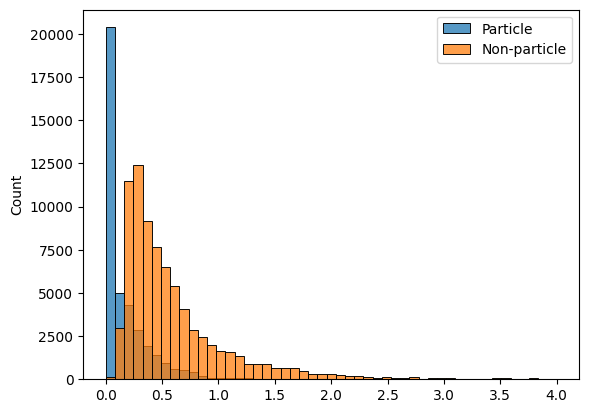

In [27]:
pt = np.sqrt(sample_event_hits["tpx"]**2 + sample_event_hits["tpy"]**2)
sns.histplot(pt[sample_event_hits.particle_id == 0], bins=np.linspace(0, 4, 50))
sns.histplot(pt[sample_event_hits.particle_id != 0], bins=np.linspace(0, 4, 50))
plt.legend(["Particle", "Non-particle"])
plt.show()

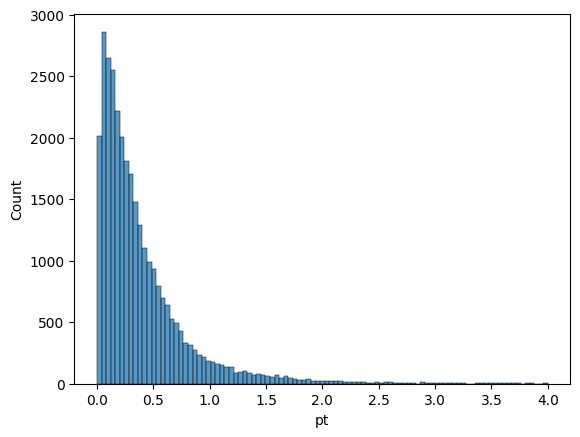

In [28]:
sns.histplot(particles_data_1.pt, bins=np.linspace(0, 4, 100))
plt.show()

In [29]:
(particles_data_1.pt > 1).sum()

2384

In [30]:
sample_event_hits[(sample_event_hits.particle_id != 0) & (sample_event_hits.pt > 1)]

,event_id_x,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
76,0,1152921779484760578,873698328850726912,146.231033,38.675564,-1523.800049,1723.558960,1.224527,0.279041,-12.330703,...,1.0,-2.980822,0.293078,1.256901,12.414878,194.0,0.0,68.0,0.0,0.0
83,0,1152921779484761090,873698327810539520,-44.015587,144.812973,-1523.800049,1723.504883,-0.640286,1.960446,-20.283743,...,-1.0,-2.980763,1.843394,2.066005,20.405525,194.0,0.0,6.0,0.0,0.0
94,0,1152921779484761346,878201927572127744,-67.574570,132.812714,-1522.599976,1409.923950,-0.499435,1.081552,-11.625600,...,1.0,-2.971069,2.078425,1.196476,11.703943,195.0,0.0,14.0,0.0,0.0
102,0,1152921779484761346,418834765630668800,-97.898346,137.851898,-1522.599976,-1609.915283,-0.790129,1.025637,-11.872658,...,-1.0,-2.910893,2.147776,1.298509,11.964217,93.0,0.0,17.0,0.0,0.0
106,0,1152921779484761602,418834765630668800,-97.978493,137.955322,-1523.800049,-1608.708008,-0.790853,1.025075,-11.872561,...,-1.0,-2.910893,2.147776,1.298509,11.964217,93.0,0.0,17.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119279,0,2161728645771605506,166633186430812160,943.057007,-79.525047,3009.500000,1341.653687,1.314445,0.173103,4.235352,...,-1.0,1.873482,-0.298525,1.347088,4.488843,37.0,0.0,13.0,0.0,0.0
119281,0,2161728645771605762,810647934218534912,855.836487,627.695801,3004.500000,3983.675049,1.203688,0.490540,3.687212,...,1.0,1.768002,0.876480,1.306121,3.937831,180.0,0.0,77.0,0.0,0.0
119288,0,2161728645771606018,810647934218534912,857.469116,628.356995,3009.500000,3989.018311,1.202735,0.489640,3.686338,...,1.0,1.768002,0.876480,1.306121,3.937831,180.0,0.0,77.0,0.0,0.0
119305,0,2161728645771606786,193654784698351616,595.604065,834.452209,3004.500000,1116.476685,0.884780,0.714095,3.169538,...,1.0,1.749231,1.222690,1.146787,3.396830,43.0,0.0,43.0,0.0,0.0


In [31]:
particle_hits_count

NameError: name 'particle_hits_count' is not defined

In [34]:
# Count number of hits per particle
particle_hits_count = sample_event_hits[(sample_event_hits.particle_id != 0) & (sample_event_hits.pt > 1)].groupby("particle_id").size()

# Merge back to get the eta
particle_hits_count = particle_hits_count.reset_index()
particle_hits_count.columns = ["particle_id", "number_of_hits"]

particle_hits_count = particle_hits_count.merge(particles_data_1, left_on="particle_id", right_on="particle_id", how="left")



932

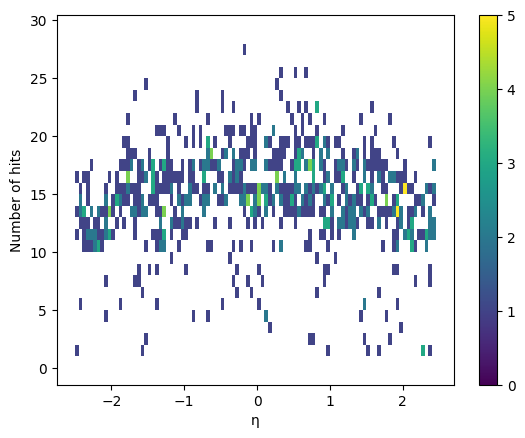

In [43]:
# Bins are eta (size 0.05) and number of hits (size 1)
g = sns.histplot(data=particle_hits_count, x="eta", y="number_of_hits", 
                 bins=[np.arange(-4, 4, 0.05), np.arange(0, 30, 1)], cmap="viridis", cbar=True)
g.set_xlabel("η")
g.set_ylabel("Number of hits")
plt.show()

<Axes: xlabel='number_of_hits', ylabel='Count'>

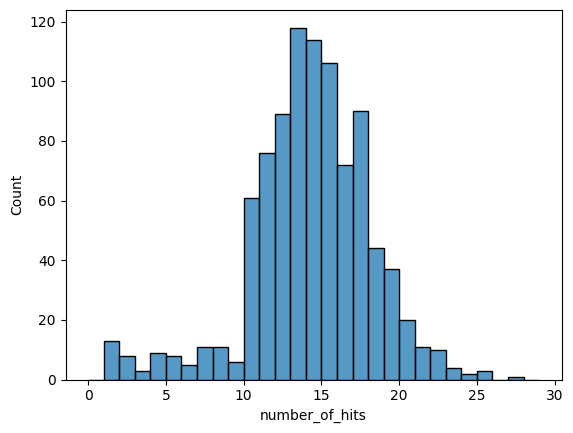

In [37]:
sns.histplot(particle_hits_count.number_of_hits, bins=np.arange(0, 30, 1))

## Geant4 event gluon-gluon

In [4]:
geant_dir = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1"

all_files = glob.glob(geant_dir + "/*.root")

In [5]:
all_files

['/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/performance_finding_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/tracksummary_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/performance_finding_ckf.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/pythia8_vertices.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/performance_vertexing.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/trackstates_ambi.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/estimatedparams.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/hits.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/measurements.root',
 '/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/performance

In [6]:
# Uproot load 
hits_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/hits.root"
hits_tree = uproot.open(hits_file)

# Get the first entry in the tree
print(hits_tree.keys()) # ['hits;7', 'hits;6']

# Get the hits data
hits_data_1 = hits_tree['hits;1'].arrays()

print(f"Lengths: {len(hits_data_1)}")
print(f"Example of hits;6: {hits_data_1[0]}")

['hits;1']
Lengths: 120984
Example of hits;6: {event_id: 0, geometry_id: 1152921779484754177, particle_id: ..., ...}


In [13]:
particles_file = "/global/cfs/cdirs/m3443/usr/dtmurnane/Side_Work/ACTS/odd_output_geant_gg_1/pythia8_particles.root"
particles_tree = uproot.open(particles_file)

print(particles_tree.keys())
particles_data_1 = particles_tree['particles;1'].arrays()

print(f"Lengths: {len(particles_data_1)}")
print(f"Example of particles: {particles_data_1[0]}")


['particles;1']
Lengths: 1
Example of particles: {event_id: 0, particle_id: [4503599644147712, ...], particle_type: [...], ...}


In [14]:
# This gives a multi index. Flatten that
particles_data_1 = ak.to_dataframe(particles_data_1)
particles_data_1 = particles_data_1.reset_index()
# Remove the "entry" and "subentry" columns
particles_data_1 = particles_data_1.drop(columns=["entry", "subentry"])


In [15]:
particles_data_1

,event_id,particle_id,particle_type,process,vx,vy,vz,vt,px,py,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
0,0,4503599644147712,321,0,-0.006878,0.006443,26.299278,2051.255127,-0.287953,-0.052705,...,1.0,2.359247,-2.960564,0.292737,1.562845,1,0,1,0,0
1,0,4503599660924928,2112,0,-0.006878,0.006443,26.299278,2051.255127,0.468179,-0.507219,...,0.0,-1.911063,-0.825401,0.690263,2.384234,1,0,2,0,0
2,0,4503599677702144,-2112,0,-0.006878,0.006443,26.299278,2051.255127,-0.329723,0.918183,...,0.0,-2.107156,1.915558,0.975590,4.071333,1,0,3,0,0
3,0,4503599694479360,211,0,-0.006878,0.006443,26.299278,2051.255127,0.664022,-0.260516,...,1.0,-3.757447,-0.373877,0.713298,15.286788,1,0,4,0,0
4,0,4503599711256576,-211,0,-0.006878,0.006443,26.299278,2051.255127,-0.580434,0.547590,...,-1.0,-8.579826,2.385303,0.797972,2123.875488,1,0,5,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31580,0,905259815226310656,22,0,0.666334,0.326563,141.230530,3949.941895,-0.061537,-0.023023,...,0.0,4.824196,-2.783576,0.065702,4.089798,201,33,372,0,0
31581,0,905260914754715648,22,0,-0.183085,-0.100399,97.511833,3906.560059,0.084413,0.016035,...,0.0,0.609824,0.187723,0.085922,0.102400,201,34,373,0,0
31582,0,905260914771492864,22,0,-0.183085,-0.100399,97.511833,3906.560059,0.031834,-0.067357,...,0.0,-0.494414,-1.129299,0.074500,0.083793,201,34,374,0,0
31583,0,905260914788270080,22,0,-0.183151,-0.100400,97.511887,3906.560059,-0.122772,0.015851,...,0.0,1.318853,3.013191,0.123791,0.247989,201,34,375,0,0


### Visualisation

In [16]:
sample_event_id = 0
sample_event_hits = hits_data_1[hits_data_1['event_id'] == sample_event_id]

In [17]:
# Convert to pandas
sample_event_hits = ak.to_dataframe(sample_event_hits)

In [18]:
sample_event_hits

,event_id,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,deltapx,deltapy,deltapz,deltae,index,volume_id,boundary_id,layer_id,approach_id,sensitive_id
entry,,,,,,,,,,,,,,,,,,,,,
0,0,1152921779484754177,905223525923618871,84.053757,-4.818307,-1515.571899,5530.034180,-0.001693,0.000048,-0.020506,...,0.000038,-0.001267,0.000958,-0.000919,6,16,0,4,0,1
1,0,1152921779484754177,905223525923684403,84.043869,-4.771657,-1515.600952,5530.084961,-0.000088,0.000933,-0.000898,...,-0.000451,-0.000171,0.000079,-0.000052,0,16,0,4,0,1
2,0,1152921779484754177,747618435290169394,102.733078,4.780591,-1515.599976,2700.387695,-0.000569,0.000024,-0.002745,...,0.000125,0.000560,0.000079,-0.000038,6,16,0,4,0,1
3,0,1152921779484754177,743093938616860753,54.844536,-3.548542,-1515.599976,4040.592041,-0.023909,-0.000662,-0.133767,...,0.000476,-0.000507,-0.000058,-0.000022,7,16,0,4,0,1
4,0,1152921779484754177,423338367355256868,56.126183,-5.384318,-1515.599976,2005.289795,-0.001236,0.001444,-0.006986,...,-0.000118,-0.000734,-0.000040,-0.000050,8,16,0,4,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120979,0,2161728645771607810,90071992782290944,405.454865,870.035461,3004.500000,5295.696777,0.182502,1.068388,3.389693,...,-0.000072,0.000027,-0.000094,-0.000085,17,30,0,12,0,191
120980,0,2161728645771608066,531424756231241963,379.133392,959.854065,3009.500000,7335.105957,-0.332430,-0.071983,0.139140,...,0.001114,0.000319,0.000469,-0.000834,1,30,0,12,0,192
120981,0,2161728645771608066,292773567576145920,321.463409,872.711060,3009.500000,945.360046,-0.216342,0.215005,0.794043,...,0.000316,-0.000009,-0.000031,-0.000110,17,30,0,12,0,192


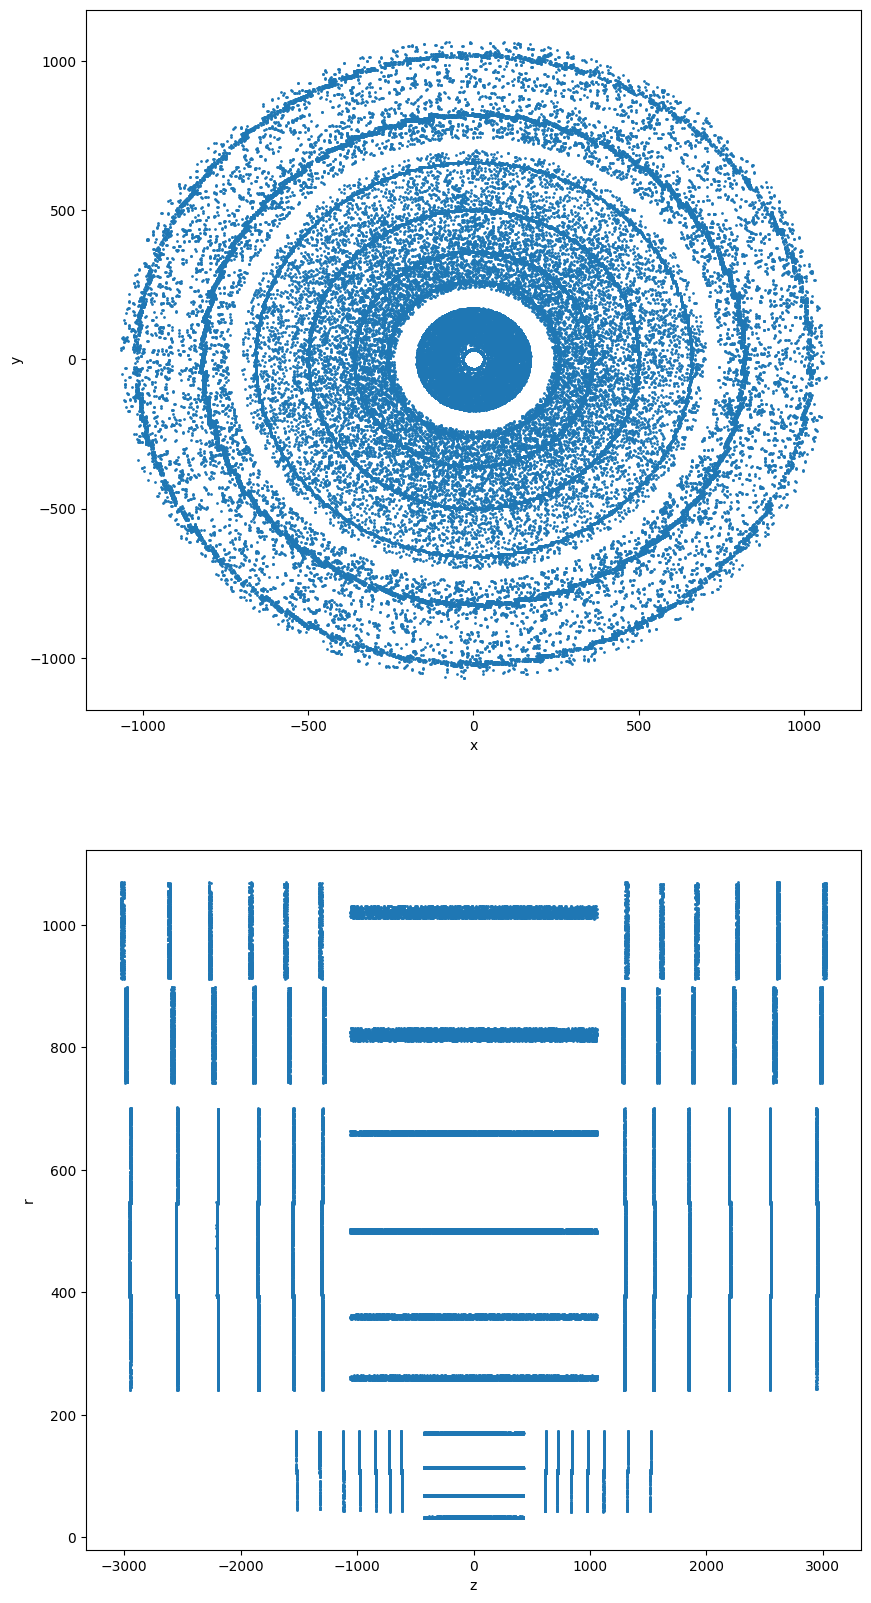

In [19]:
x, y, z = sample_event_hits['tx'], sample_event_hits['ty'], sample_event_hits['tz']
r, phi = np.sqrt(x**2 + y**2), np.arctan2(y, x)

# Plot x,y and r,z
fig, ax = plt.subplots(2, 1, figsize=(10, 20))
ax[0].scatter(x, y, s=1)
ax[1].scatter(z, r, s=1)
ax[0].set_xlabel('x')
ax[0].set_ylabel('y')
ax[1].set_xlabel('z')
ax[1].set_ylabel('r')
plt.show()

In [20]:
sample_event_hits = sample_event_hits.merge(particles_data_1, left_on="particle_id", right_on="particle_id", how="left")

In [21]:
sample_event_hits.loc[sample_event_hits.q.isna(), "particle_id"] = 0

In [22]:
sample_event_hits

,event_id_x,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
0,0,1152921779484754177,0,84.053757,-4.818307,-1515.571899,5530.034180,-0.001693,0.000048,-0.020506,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,0,1152921779484754177,0,84.043869,-4.771657,-1515.600952,5530.084961,-0.000088,0.000933,-0.000898,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,0,1152921779484754177,0,102.733078,4.780591,-1515.599976,2700.387695,-0.000569,0.000024,-0.002745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,0,1152921779484754177,0,54.844536,-3.548542,-1515.599976,4040.592041,-0.023909,-0.000662,-0.133767,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,0,1152921779484754177,0,56.126183,-5.384318,-1515.599976,2005.289795,-0.001236,0.001444,-0.006986,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120979,0,2161728645771607810,90071992782290944,405.454865,870.035461,3004.500000,5295.696777,0.182502,1.068388,3.389693,...,-1.0,1.862584,0.866533,1.085913,3.581138,20.0,0.0,14.0,0.0,0.0
120980,0,2161728645771608066,0,379.133392,959.854065,3009.500000,7335.105957,-0.332430,-0.071983,0.139140,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
120981,0,2161728645771608066,292773567576145920,321.463409,872.711060,3009.500000,945.360046,-0.216342,0.215005,0.794043,...,-1.0,1.678985,0.107337,0.314717,0.872818,65.0,36.0,559.0,0.0,0.0
120982,0,2161728645771608066,0,394.361847,916.529968,3009.500000,249.281723,-0.001535,0.000581,0.011389,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


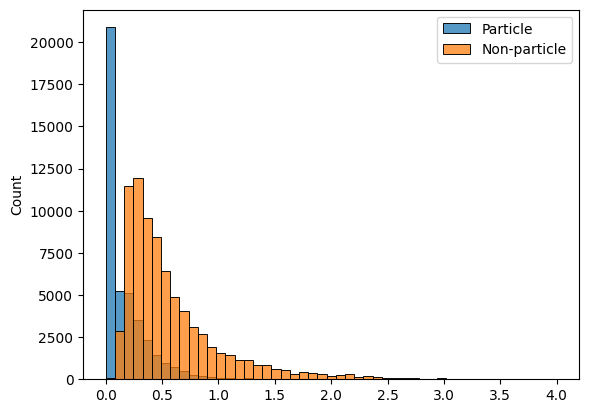

In [23]:
pt = np.sqrt(sample_event_hits["tpx"]**2 + sample_event_hits["tpy"]**2)
sns.histplot(pt[sample_event_hits.particle_id == 0], bins=np.linspace(0, 4, 50))
sns.histplot(pt[sample_event_hits.particle_id != 0], bins=np.linspace(0, 4, 50))
plt.legend(["Particle", "Non-particle"])
plt.show()

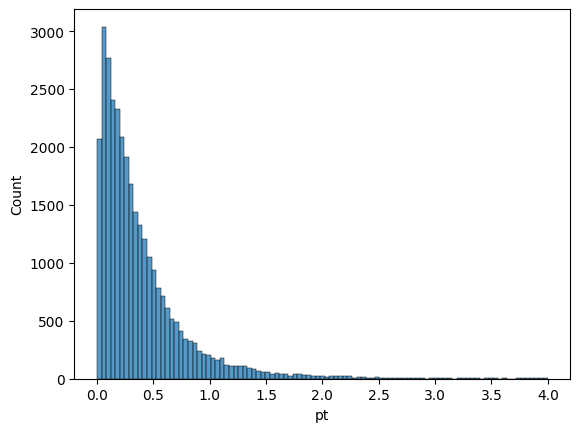

In [24]:
sns.histplot(particles_data_1.pt, bins=np.linspace(0, 4, 100))
plt.show()

In [25]:
(particles_data_1.pt > 1).sum()

2243

In [26]:
sample_event_hits[(sample_event_hits.particle_id != 0) & (sample_event_hits.pt > 1)]

,event_id_x,geometry_id,particle_id,tx,ty,tz,tt,tpx,tpy,tpz,...,q,eta,phi,pt,p,vertex_primary,vertex_secondary,particle,generation,sub_particle
82,0,1152921779484760578,770115536397795328,160.786819,30.935469,-1523.800049,-1925.612793,1.585234,0.253203,-14.994078,...,1.0,-2.930667,0.221468,1.607337,15.103739,171.0,0.0,7.0,0.0,0.0
83,0,1152921779484760578,522417557848719360,159.160522,39.551804,-1523.800049,4027.745361,1.746021,0.483652,-16.357391,...,-1.0,-2.889078,0.216822,1.827433,16.476471,116.0,0.0,64.0,0.0,0.0
84,0,1152921779484760578,342327456692174848,150.997421,23.808769,-1523.800049,-1161.274292,1.210487,0.137553,-11.607723,...,1.0,-2.948940,0.193048,1.221828,11.691736,76.0,49.0,533.0,0.0,0.0
114,0,1152921779484761602,283726777564528640,-104.014534,127.850807,-1523.800049,3914.627686,-0.680919,0.763392,-9.800606,...,-1.0,-2.961895,2.207263,1.018491,9.872377,63.0,0.0,62.0,0.0,0.0
136,0,1152921779484762626,725079540442857472,-147.955582,16.092136,-1523.800049,618.695618,-2.383366,0.216927,-23.710943,...,-1.0,-2.992164,3.013904,2.387568,23.850536,161.0,0.0,26.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
120954,0,2161728645771607042,391813167732228096,636.149231,814.281494,3009.500000,4641.479004,1.021253,0.806145,3.654786,...,1.0,1.760892,1.147986,1.302100,3.899475,87.0,0.0,9.0,0.0,0.0
120957,0,2161728645771607298,644014746982416384,537.338806,803.389526,3025.500000,4063.766113,0.810500,1.741746,5.917914,...,-1.0,1.843881,0.824728,1.928095,6.246279,143.0,0.0,16.0,0.0,0.0
120968,0,2161728645771607554,644014746982416384,536.654175,801.918579,3020.500000,4058.508301,0.810756,1.741669,5.919058,...,-1.0,1.843881,0.824728,1.928095,6.246279,143.0,0.0,16.0,0.0,0.0
120979,0,2161728645771607810,90071992782290944,405.454865,870.035461,3004.500000,5295.696777,0.182502,1.068388,3.389693,...,-1.0,1.862584,0.866533,1.085913,3.581138,20.0,0.0,14.0,0.0,0.0


In [27]:
particle_hits_count

NameError: name 'particle_hits_count' is not defined

In [28]:
# Count number of hits per particle
particle_hits_count = sample_event_hits[(sample_event_hits.particle_id != 0) & (sample_event_hits.pt > 1)].groupby("particle_id").size()

# Merge back to get the eta
particle_hits_count = particle_hits_count.reset_index()
particle_hits_count.columns = ["particle_id", "number_of_hits"]

particle_hits_count = particle_hits_count.merge(particles_data_1, left_on="particle_id", right_on="particle_id", how="left")



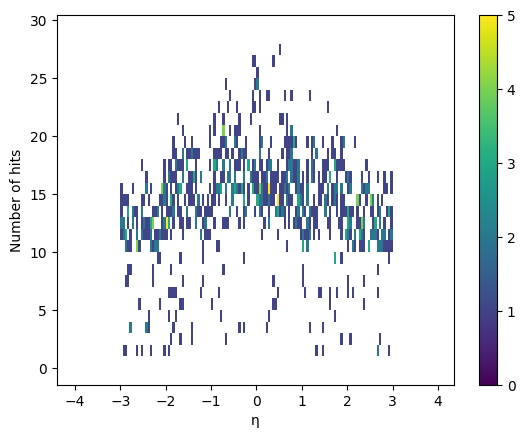

In [29]:
# Bins are eta (size 0.05) and number of hits (size 1)
g = sns.histplot(data=particle_hits_count, x="eta", y="number_of_hits", 
                 bins=[np.arange(-4, 4, 0.05), np.arange(0, 30, 1)], cmap="viridis", cbar=True)
g.set_xlabel("η")
g.set_ylabel("Number of hits")
plt.show()